In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import shap
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load cleaned data
df = pd.read_csv('telco_churn_cleaned.csv')

# Encode target
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Encode binary columns
binary_mapping = {
    'gender': {'Female': 0, 'Male': 1},
    'Partner': {'Yes': 1, 'No': 0},
    'Dependents': {'Yes': 1, 'No': 0},
    'PhoneService': {'Yes': 1, 'No': 0},
    'PaperlessBilling': {'Yes': 1, 'No': 0}
}
for col, mapping in binary_mapping.items():
    df[col] = df[col].map(mapping)

# One hot encode
df = pd.get_dummies(df, columns=[
    'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
], drop_first=True)

# Drop TotalCharges
df = df.drop('TotalCharges', axis=1)

# Split
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale
scaler = StandardScaler()
numerical_cols = ['tenure', 'MonthlyCharges']
X_train[numerical_cols] = scaler.fit_transform(
    X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(
    X_test[numerical_cols])

print("Data loaded and preprocessed.")
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Data loaded and preprocessed.
Train shape: (5634, 29)
Test shape: (1409, 29)


In [2]:
best_xgb= xgb.XGBClassifier(
    subsample=0.9,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
best_xgb.fit(X_train,y_train)
print("Model retrained successfully.")

#Create SHAP explainer
explainer=shap.TreeExplainer(best_xgb)

#Calculate SHAP values for all test customers
shap_values= explainer.shap_values(X_test)

print("SHAP values calculated.")
print("Shape of SHAP values:", shap_values.shape)

Model retrained successfully.
SHAP values calculated.
Shape of SHAP values: (1409, 29)


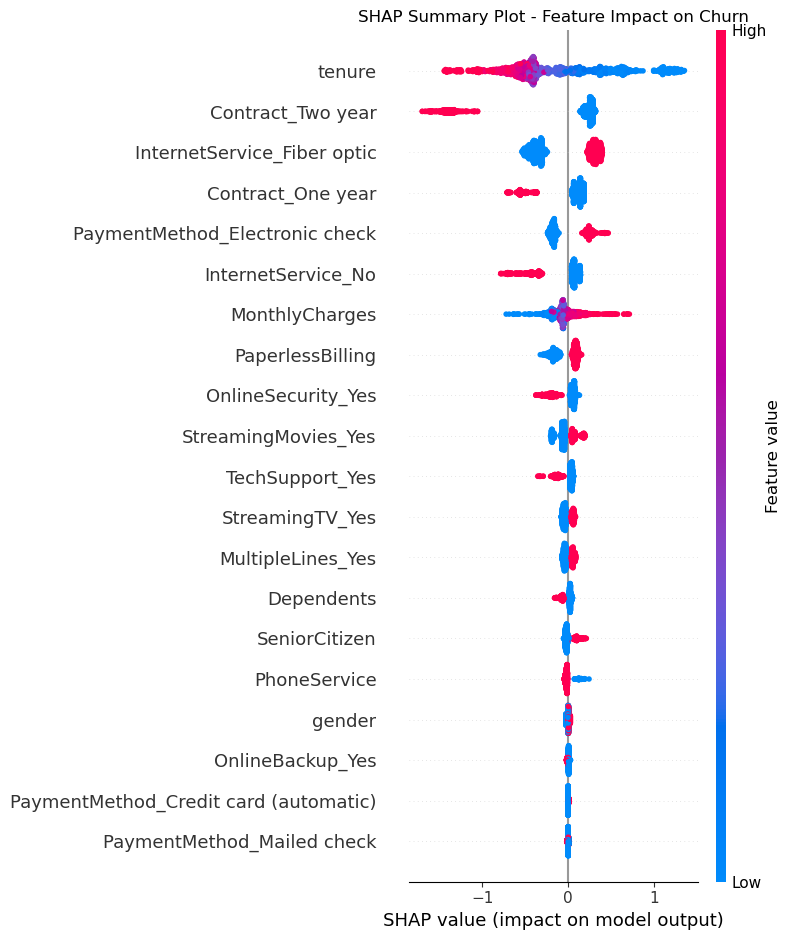

Summary plot saved.


In [3]:
plt.figure(figsize=(10,8))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X_test.columns.tolist(),
    show=False
)

plt.title("SHAP Summary Plot - Feature Impact on Churn")
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Summary plot saved.")

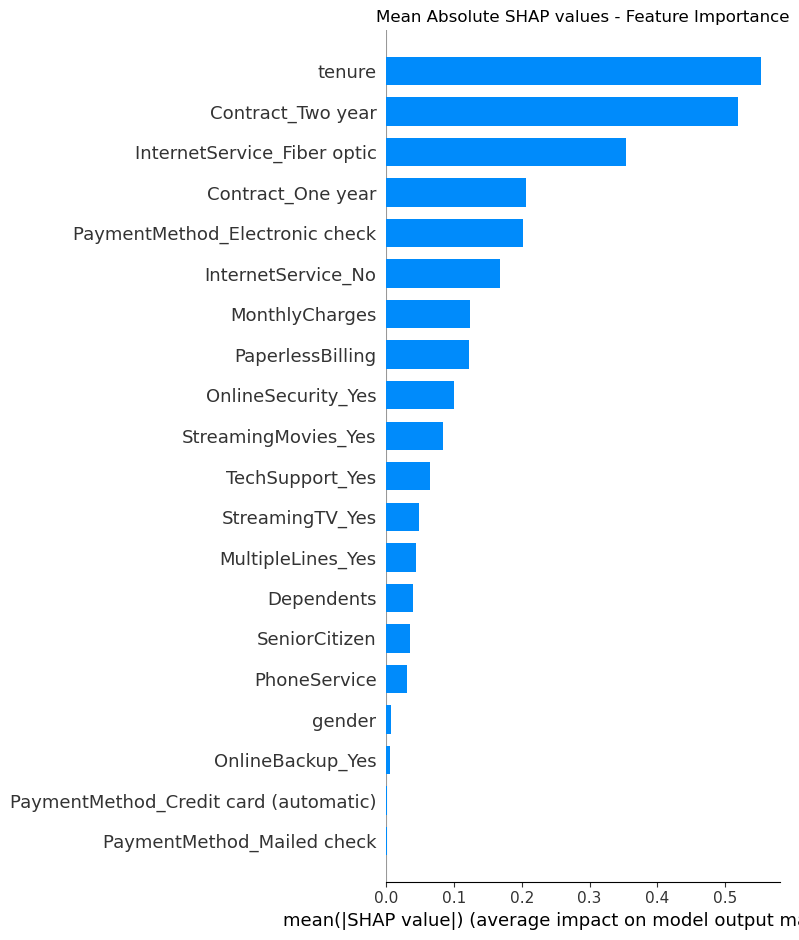

Bar plot saved.


In [7]:
plt.figure(figsize=(10,8))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X_test.columns.tolist(),
    plot_type="bar",
    show=False
)
plt.title("Mean Absolute SHAP values - Feature Importance")
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Bar plot saved.")

Highest risk customer index: 1090
Churn probablity: 93.4000015258789%
Actual churn: Yes


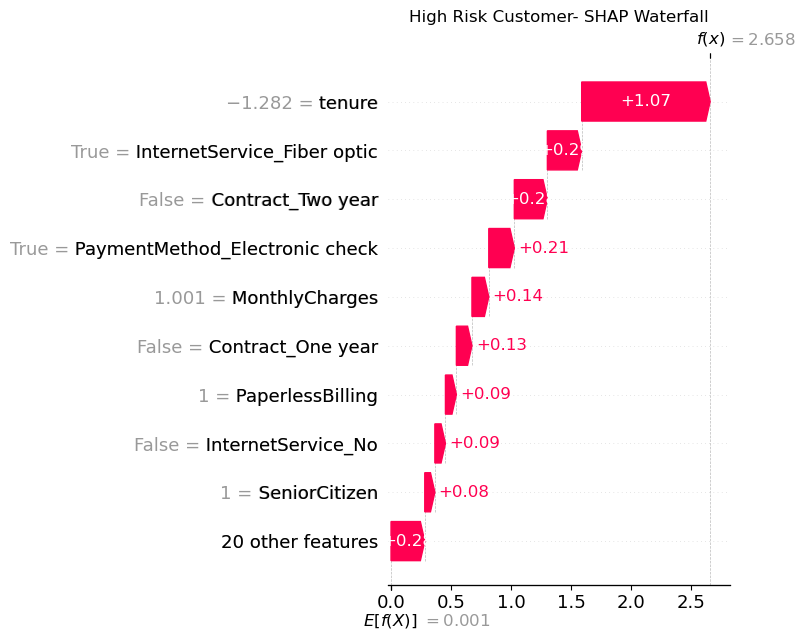

In [11]:
#Find a high risk customer
y_pred_proba= best_xgb.predict_proba(X_test)[:,1]
high_risk_idx= y_pred_proba.argmax()

print(f"Highest risk customer index: {high_risk_idx}")
print(f"Churn probablity: {round(y_pred_proba[high_risk_idx]*100,1)}%")
print(f"Actual churn: {'Yes' if y_test.iloc[high_risk_idx]==1 else 'No'}")

#Waterfall plot for high risk customer
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[high_risk_idx],
        feature_names=X_test.columns.tolist()
    ),
    show=False
)
plt.title("High Risk Customer- SHAP Waterfall")
plt.tight_layout()
plt.savefig('shap_waterfall_high_risk.png',
            dpi=150, bbox_inches='tight')
plt.show()

Lowest risk customer index: 60
Churn probability: 1.899999976158142%
Actual churn: No


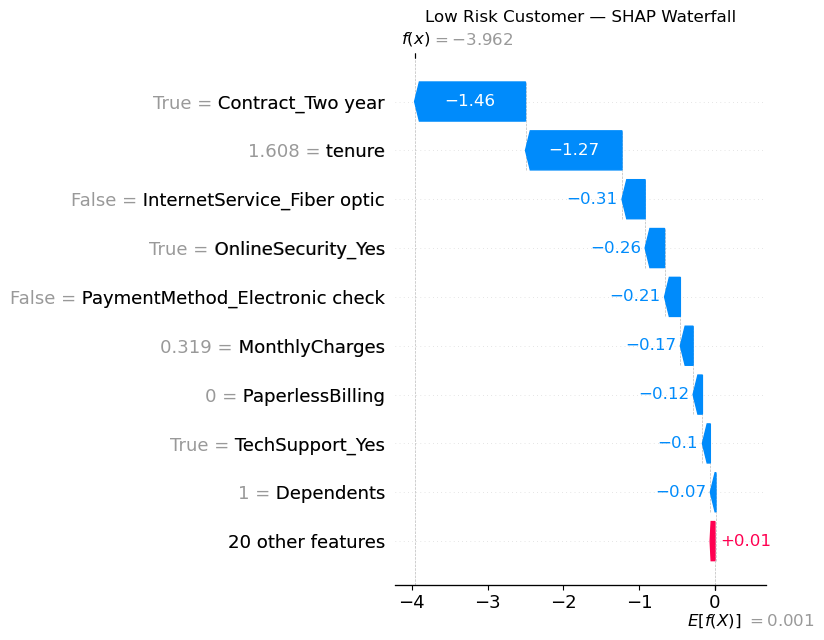

In [12]:
# Find lowest risk customer
low_risk_idx = y_pred_proba.argmin()

print(f"Lowest risk customer index: {low_risk_idx}")
print(f"Churn probability: {round(y_pred_proba[low_risk_idx]*100, 1)}%")
print(f"Actual churn: {'Yes' if y_test.iloc[low_risk_idx]==1 else 'No'}")

# Waterfall plot for low risk customer
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[low_risk_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[low_risk_idx],
        feature_names=X_test.columns.tolist()
    ),
    show=False
)
plt.title("Low Risk Customer — SHAP Waterfall")
plt.tight_layout()
plt.savefig('shap_waterfall_low_risk.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [13]:
import pickle

# Save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save model
with open('best_xgb_model.pkl', 'wb') as f:
    pickle.dump(best_xgb, f)

# Save feature names for deployment
feature_names = X_test.columns.tolist()
with open('feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

print("All files saved:")
print("- best_xgb_model.pkl")
print("- scaler.pkl")
print("- feature_names.pkl")
print("\nSHAP plots saved:")
print("- shap_summary.png")
print("- shap_bar.png")
print("- shap_waterfall_high_risk.png")
print("- shap_waterfall_low_risk.png")

All files saved:
- best_xgb_model.pkl
- scaler.pkl
- feature_names.pkl

SHAP plots saved:
- shap_summary.png
- shap_bar.png
- shap_waterfall_high_risk.png
- shap_waterfall_low_risk.png
